Load Data

In [2]:
import sklearn; print(sklearn.__version__)

1.9.1


In [3]:
import pandas as pd, numpy as np, json, joblib
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

df = pd.read_csv("Customer_Data.csv")
print(df.shape); print(df.dtypes); df.head()

Matplotlib is building the font cache; this may take a moment.


(7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Data quality

In [4]:
# TotalCharges is text: 11 blank values (all have tenure = 0, i.e. new customers)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(df.isna().sum()[lambda s: s > 0])
print(df.loc[df["TotalCharges"].isna(), ["tenure", "TotalCharges"]].head())
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("Duplicates:", df.duplicated().sum())

df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})
print(df["Churn"].value_counts(normalize=True))   # ~73.5% stay / 26.5% churn

TotalCharges    11
dtype: int64
      tenure  TotalCharges
488        0           NaN
753        0           NaN
936        0           NaN
1082       0           NaN
1340       0           NaN
Duplicates: 0
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


EDA

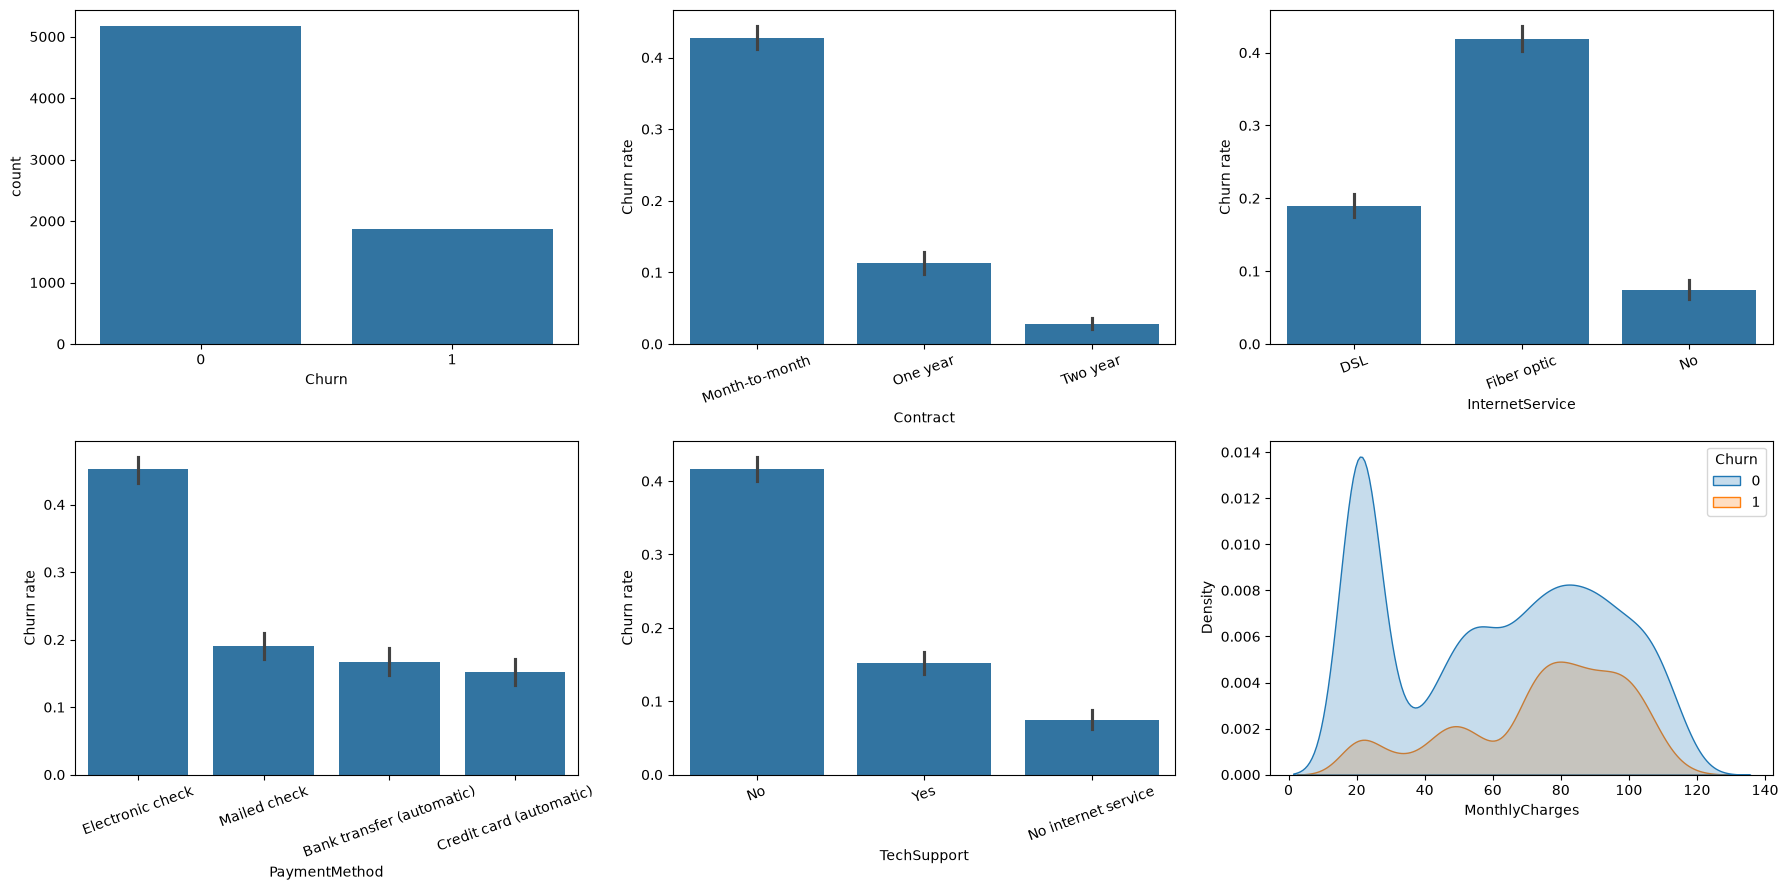

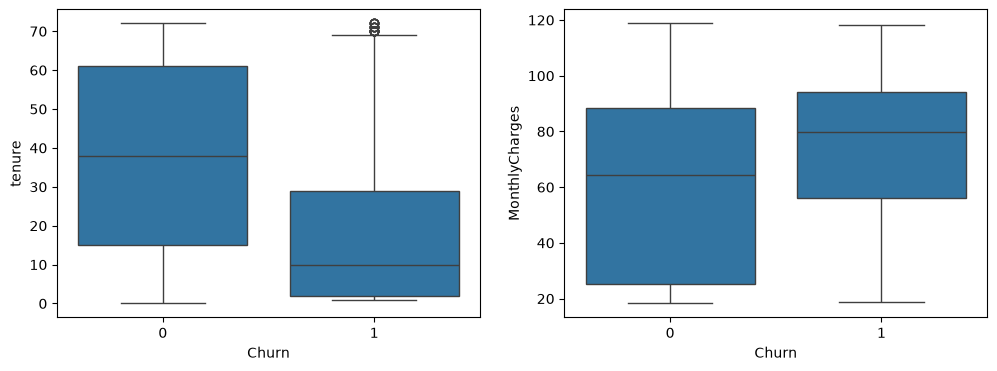

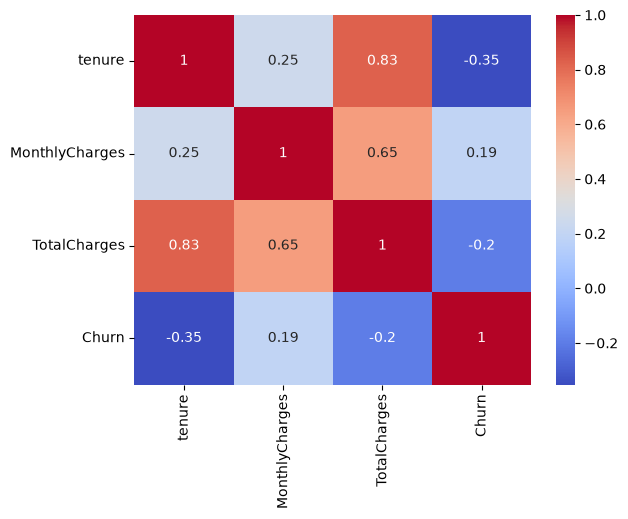

In [5]:
fig, ax = plt.subplots(2, 3, figsize=(18, 9))
sns.countplot(x="Churn", data=df, ax=ax[0, 0])
for a, c in zip(ax.flat[1:5], ["Contract", "InternetService", "PaymentMethod", "TechSupport"]):
    sns.barplot(x=c, y="Churn", data=df, ax=a)
    a.tick_params(axis="x", rotation=20); a.set_ylabel("Churn rate")
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True, ax=ax[1, 2])
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x="Churn", y="tenure", data=df, ax=ax[0])
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, ax=ax[1]); plt.show()

sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr(), annot=True, cmap="coolwarm"); plt.show()

Define X, y, feature types, split

In [6]:
# customerID = identifier. MultipleLines is dropped so the model inputs match the Streamlit form exactly.
X = df.drop(columns=["customerID", "MultipleLines", "Churn"])
y = df["Churn"]

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in X.columns if c not in num_cols]
print("Numerical:", num_cols); print("Categorical:", cat_cols)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Numerical: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Preprocessing and 3 models

In [7]:
def make_pipe(model):
    pre = ColumnTransformer([("num", StandardScaler(), num_cols),
                             ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])
    return Pipeline([("pre", pre), ("model", model)])

models = {
    "Logistic Regression": make_pipe(LogisticRegression(max_iter=1000, class_weight="balanced")),
    "Decision Tree": make_pipe(DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42)),
    "Random Forest": make_pipe(RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)),
}

def evaluate(name, pipe):
    pred = pipe.predict(X_test); proba = pipe.predict_proba(X_test)[:, 1]
    return {"Model": name, "Accuracy": accuracy_score(y_test, pred), "Precision": precision_score(y_test, pred),
            "Recall": recall_score(y_test, pred), "F1": f1_score(y_test, pred), "ROC-AUC": roc_auc_score(y_test, proba)}

rows = []
for n, p in models.items():
    p.fit(X_train, y_train)        # predictions are generated inside evaluate()
    rows.append(evaluate(n, p))
baseline = pd.DataFrame(rows).set_index("Model").round(3)
baseline

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.739,0.505,0.789,0.616,0.842
Decision Tree,0.754,0.526,0.757,0.621,0.832
Random Forest,0.768,0.555,0.631,0.591,0.823


Confusion matrices and class imbalance

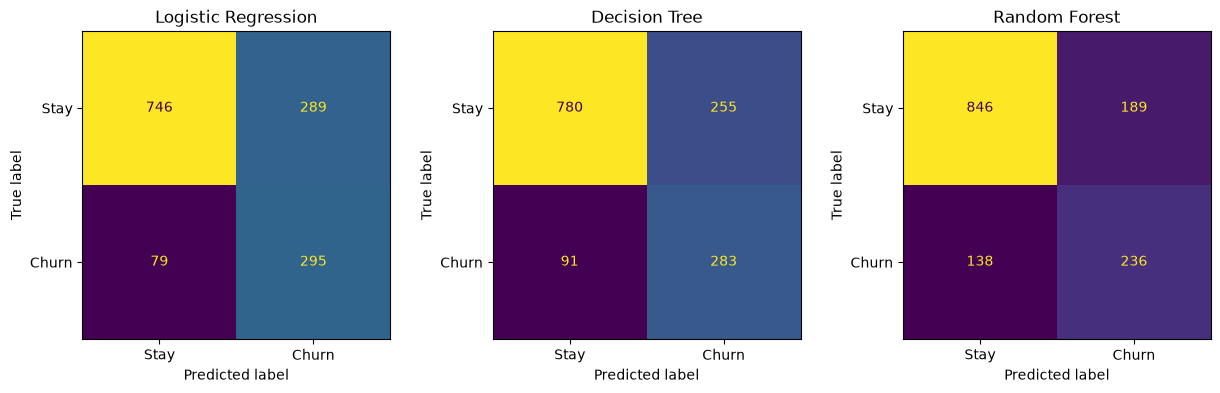

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, (n, p) in zip(ax, models.items()):
    ConfusionMatrixDisplay.from_estimator(p, X_test, y_test, display_labels=["Stay", "Churn"], ax=a, colorbar=False)
    a.set_title(n)
plt.show()
# Imbalance: only 26.5% churn, so accuracy is misleading. class_weight="balanced" is used to counter it.

Prediction probabilities and threshold

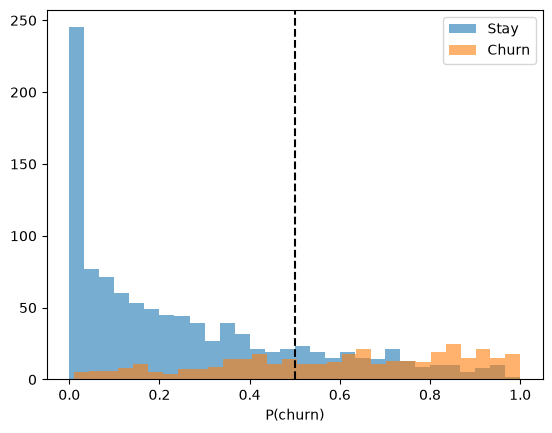

t=0.3: precision=0.473 recall=0.845 f1=0.607
t=0.4: precision=0.525 recall=0.751 f1=0.618
t=0.5: precision=0.551 recall=0.634 f1=0.590
t=0.6: precision=0.599 recall=0.543 f1=0.569


In [9]:
proba = models["Random Forest"].predict_proba(X_test)[:, 1]
plt.hist(proba[y_test == 0], bins=30, alpha=.6, label="Stay")
plt.hist(proba[y_test == 1], bins=30, alpha=.6, label="Churn")
plt.axvline(.5, color="k", ls="--"); plt.legend(); plt.xlabel("P(churn)"); plt.show()

for t in [0.3, 0.4, 0.5, 0.6]:
    pr = (proba >= t).astype(int)
    print(f"t={t}: precision={precision_score(y_test, pr):.3f} recall={recall_score(y_test, pr):.3f} f1={f1_score(y_test, pr):.3f}")

Hyperparameter tuning

In [10]:
grid = {"model__n_estimators": [200, 400], "model__max_depth": [6, 10, None],
        "model__min_samples_leaf": [1, 5, 10], "model__max_features": ["sqrt", 0.5]}
gs = GridSearchCV(make_pipe(RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)),
                  grid, scoring="f1", cv=StratifiedKFold(5, shuffle=True, random_state=42), n_jobs=-1)
gs.fit(X_train, y_train)
print(gs.best_params_, round(gs.best_score_, 3))
final_model = gs.best_estimator_

{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 200} 0.634


Final evaluation

                     Accuracy  Precision  Recall     F1  ROC-AUC
Model                                                           
Tuned Random Forest     0.757      0.528   0.775  0.628    0.842
              precision    recall  f1-score   support

        Stay       0.90      0.75      0.82      1035
       Churn       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



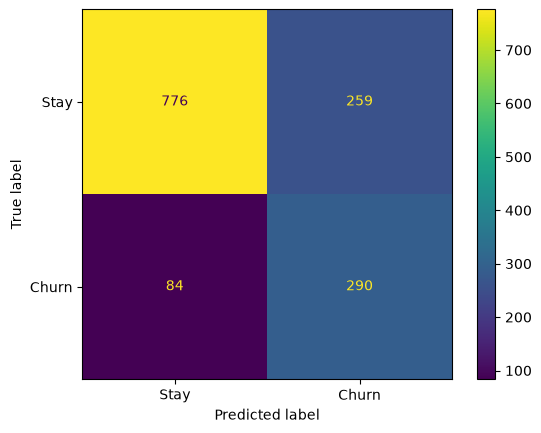

In [11]:
final_res = evaluate("Tuned Random Forest", final_model)
final_df = pd.DataFrame([final_res]).set_index("Model").round(3)
print(final_df)

y_pred = final_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Stay", "Churn"]))
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test, display_labels=["Stay", "Churn"]); plt.show()

Feature importance

cat__Contract_Month-to-month           0.141713
num__tenure                            0.120025
num__TotalCharges                      0.098796
cat__OnlineSecurity_No                 0.069841
cat__Contract_Two year                 0.069788
num__MonthlyCharges                    0.067007
cat__TechSupport_No                    0.057030
cat__InternetService_Fiber optic       0.048485
cat__PaymentMethod_Electronic check    0.036916
cat__InternetService_DSL               0.019242
dtype: float64


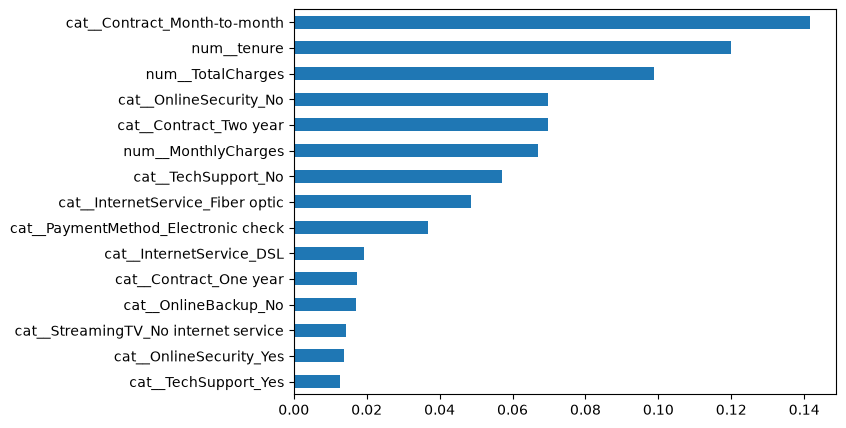

In [12]:
names = final_model.named_steps["pre"].get_feature_names_out()
fi = pd.Series(final_model.named_steps["model"].feature_importances_, index=names).sort_values(ascending=False)
print(fi.head(10))
fi.head(15).sort_values().plot.barh(figsize=(7, 5)); plt.show()

Predict for new customers

In [13]:
new = pd.DataFrame([
 {"gender":"Female","SeniorCitizen":0,"Partner":"No","Dependents":"No","tenure":2,"PhoneService":"Yes","InternetService":"Fiber optic","OnlineSecurity":"No","OnlineBackup":"No","DeviceProtection":"No","TechSupport":"No","StreamingTV":"Yes","StreamingMovies":"Yes","Contract":"Month-to-month","PaperlessBilling":"Yes","PaymentMethod":"Electronic check","MonthlyCharges":95.0,"TotalCharges":190.0},
 {"gender":"Male","SeniorCitizen":0,"Partner":"Yes","Dependents":"Yes","tenure":60,"PhoneService":"Yes","InternetService":"DSL","OnlineSecurity":"Yes","OnlineBackup":"Yes","DeviceProtection":"Yes","TechSupport":"Yes","StreamingTV":"No","StreamingMovies":"No","Contract":"Two year","PaperlessBilling":"No","PaymentMethod":"Bank transfer (automatic)","MonthlyCharges":65.0,"TotalCharges":3900.0},
 {"gender":"Male","SeniorCitizen":1,"Partner":"No","Dependents":"No","tenure":14,"PhoneService":"Yes","InternetService":"Fiber optic","OnlineSecurity":"No","OnlineBackup":"Yes","DeviceProtection":"No","TechSupport":"No","StreamingTV":"No","StreamingMovies":"No","Contract":"One year","PaperlessBilling":"Yes","PaymentMethod":"Credit card (automatic)","MonthlyCharges":80.0,"TotalCharges":1120.0},
])
new["Churn Probability"] = final_model.predict_proba(new)[:, 1].round(3)
new["Prediction"] = np.where(new["Churn Probability"] >= 0.5, "Churn", "No Churn")
new[["tenure", "Contract", "InternetService", "Churn Probability", "Prediction"]]

,tenure,Contract,InternetService,Churn Probability,Prediction
0,2,Month-to-month,Fiber optic,0.933,Churn
1,60,Two year,DSL,0.022,No Churn
2,14,One year,Fiber optic,0.393,No Churn


Save everything the app needs

In [14]:
joblib.dump(final_model, "artifacts/churn_pipeline.joblib")
allm = pd.concat([baseline, pd.DataFrame([final_res]).set_index("Model").round(3)])
allm.to_csv("artifacts/model_comparison.csv")
fi.to_csv("artifacts/feature_importance.csv", header=["importance"])
json.dump({"confusion_matrix": confusion_matrix(y_test, y_pred).tolist(), "best_params": gs.best_params_},
          open("artifacts/final_meta.json", "w"))
allm

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.739,0.505,0.789,0.616,0.842
Decision Tree,0.754,0.526,0.757,0.621,0.832
Random Forest,0.768,0.555,0.631,0.591,0.823
Tuned Random Forest,0.757,0.528,0.775,0.628,0.842
